### Stochastic interpolant with **equivariant OT**: COM-free Gaussian → LJ13 cluster

The LJ13 analogue of `XY_chain_eqOT.ipynb`. Instead of training from scratch, we warm-start
the drift from the released **`LJ13_eq_OT_flow_matching`** checkpoint (Klein, Kraemer & Noé
2023; OSF [srqg7](https://osf.io/srqg7/)) and learn a score field alongside it, turning a
plain flow into a proper stochastic interpolant.

- `load_ref_data`  — the target dataset `p₁`: OSF MCMC samples of the 13-atom LJ cluster.
- `sample_prior`   — the base `p₀`: COM-free unit Gaussian on the 36-dim mean-zero subspace.
- `make_si_model`  — an `LJ13EESI` wrapping two `LJ13Dynamics` E(n)-GNNs (drift + score).
- `si_step` / `train_si` — one coupled step / the full loop. The coupling
  (`eesi.ot.equivariant_ot_couple`) runs under `no_grad` and just re-pairs the batch before
  `model.loss`, so nothing about the interpolant changes.

The coupling has two independent layers, toggled per call: `align` (OT over the symmetry
group S(13) × SO(3)) and `batch` (minibatch OT over the batch). For LJ13 the group is large
and `align` dominates — the opposite of the XY chain, where the group is tiny. See
`eesi/ot.py`.

**Conventions** (resolved in `eesi/models/lj13_dynamics.py`, do not re-derive): t=0 → prior,
t=1 → target; states are `(B, 13, 3)` and mean-free throughout; everything is float64.

### 0. Imports & environment

In [ ]:
# --- imports & environment ---
import sys
import pathlib
import time

import numpy as np
import torch
import matplotlib.pyplot as plt

plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['font.sans-serif'] = ['Arial']

# Make the `eesi` package importable whether the notebook is launched from the
# repo root or from this experiments/ folder (no install required).
_cwd = pathlib.Path.cwd()
for _root in (_cwd, _cwd.parent):
    if (_root / "eesi" / "__init__.py").exists():
        sys.path.insert(0, str(_root))
        break

from eesi.datasets.lj13 import load_ref_data, sample_prior, lj_energy
from eesi.models.lj13_dynamics import LJ13Dynamics, rk4_sample, integrate_with_logdet
from eesi.ot import equivariant_ot_couple, transport_cost
from eesi.train.lj13 import make_si_model, train_si

%matplotlib inline
torch.set_default_dtype(torch.float64)   # the train hooks default to float64
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

Using device: cuda


#### 0.1. Some useful functions

In [2]:
_IU = torch.triu_indices(13, 13, offset=1)          # the 78 unique pairs

def pair_distances(x):                              # (B,13,3) -> (B*78,) all pair distances
    iu = _IU.to(x.device)
    d = x[:, iu[0]] - x[:, iu[1]]
    return d.pow(2).sum(-1).sqrt().reshape(-1).cpu().numpy()

def energy(x):                                      # physical (i<j) LJ energy, min = -44.327
    return lj_energy(x, ordered=False).cpu().numpy()

def smooth(v, k=25):
    v = np.asarray(v)
    return np.convolve(v, np.ones(k) / k, mode="valid") if len(v) >= k else v

# Apply a sampler to x0 in chunks. The ODE/SDE have no batch coupling, so this is
# exactly equivalent to one big call -- it only caps peak GPU memory (13 atoms x
# 156 directed edges per config adds up fast at B=5000).
@torch.no_grad()
def chunked(fn, x0, size=1000):
    return torch.cat([fn(c) for c in x0.split(size)])

### 1. Datasets & samplers

`load_ref_data` slices the memory-mapped 10M × 39 OSF array *before* materializing it, so we
never pull the full 1.5 GB into RAM. The shipped configurations are already COM-free;
re-centering only removes float drift. `sample_prior` is the base `p₀`, drawn fresh each
step. Both distributions are S(13) × SO(3)-invariant, which is what makes the
equivariant-OT coupling marginal-preserving.

In [5]:
n_data = 100_000
x1_all = load_ref_data(n=n_data).to(device)
print("target dataset:", tuple(x1_all.shape))

x0_demo = sample_prior(4, device=device)
print("base sample   :", tuple(x0_demo.shape))


e_ref = energy(x1_all[:100_000])
print(f"reference energy: <E> = {e_ref.mean():+.3f}   min = {e_ref.min():+.3f} "
      f"(global minimum is -44.327)")

target dataset: (100000, 13, 3)
base sample   : (4, 13, 3)
reference energy: <E> = -26.122   min = -35.318 (global minimum is -44.327)


#### 1.1. What the coupling buys

The 2×2 of `align` (OT over the group) and `batch` (OT over the minibatch). The reported
number is the mean squared transport cost `‖x₀ − x₁‖²` of the resulting pairing — lower is a
straighter, easier-to-learn path. Unlike the XY chain, LJ13 has a large symmetry group, so
`align` should carry most of the reduction.

In [6]:
torch.seed()
batch_size = 256   # held FIXED across training, sampling, and entropy -- see the note below

_x1 = x1_all[torch.randint(0, n_data, (batch_size,), device=device)]
_x0 = sample_prior(batch_size, device=device)

base = None
for align, batch in [(False, False), (False, True), (True, False), (True, True)]:
    a, b = equivariant_ot_couple(_x0, _x1, align=align, batch=batch)
    c = transport_cost(a, b).item()
    base = c if base is None else base
    label = f"align={str(align):5s} batch={str(batch):5s}"
    print(f"{label}  transport {c:8.2f}   ({100 * (c / base - 1):+6.1f}% vs random)")

align=False batch=False  transport    54.51   (  +0.0% vs random)
align=False batch=True   transport    33.27   ( -39.0% vs random)
align=True  batch=False  transport    14.13   ( -74.1% vs random)
align=True  batch=True   transport     9.40   ( -82.8% vs random)


> **Batch size is load-bearing.** The minibatch-OT layer makes the coupling — and therefore
> the time-dependent marginals the model is fit to — depend on the batch size. Keep
> `batch_size` identical in training and in any downstream estimate that re-couples
> (§5). Sampling in §4 involves no coupling, so chunking there is free.

### 2. Model & checkpoint load

`make_si_model` returns an `LJ13EESI` wrapping two independent `LJ13Dynamics` E(n)-GNNs, one
for the drift `b` and one for the score `s`. We use the **linear** path, matching the
convention the released checkpoint was trained under, with a `sqrt` latent-noise schedule so
the score trains against the cheap antithetic denoising objective rather than implicit score
matching.

The checkpoint is a *flow-matching velocity*, i.e. exactly `b(t,x) = E[x₁ − x₀ | x_t]` for
the **noiseless** linear interpolant. Switching on the latent noise (`gamma_scale > 0`)
smears the marginals slightly, so the checkpoint is a close **warm start** for `net_b`, not
the exact optimum — it lands the drift in the right basin and training refines it from
there. `net_s` starts from scratch.

In [7]:
model = make_si_model(
    n_particles=13, n_dims=3,
    path="linear", gamma="sin2", gamma_scale=0.1,
    score_div_method="exact",learn_score=False
).to(device=device, dtype=torch.float64)

print("net_b params:", sum(p.numel() for p in model.net_b.parameters()))
print("net_s params:", sum(p.numel() for p in model.net_s.parameters()))

# Warm-start the drift from the released OSF equivariant-OT flow-matching checkpoint.
ckpt = LJ13Dynamics.from_checkpoint().to(device=device, dtype=torch.float64)

# warm-start the 
#model.net_b.load_state_dict(fm_only)
model.net_b.load_state_dict(torch.load("lj13_b_si_B256.pth"))
model.net_s.load_state_dict(torch.load("lj13_s_si_B256.pth"))

net_b params: 22468
net_s params: 22468


<All keys matched successfully>

#### 2.1. Baseline: the checkpoint on its own

Push the prior through the raw checkpoint with the RK4 integrator it was validated with.
This is the bar the trained interpolant has to hold onto — a warm start that gets *worse*
after training means the learning rate knocked the drift out of its basin.

In [8]:
torch.seed()
x0_base = sample_prior(2_000, device=device)
gen_ckpt = chunked(lambda c: rk4_sample(ckpt, c, n_steps=50), x0_base)
e_ckpt = energy(gen_ckpt)
print(f"checkpoint (RK4): <E> = {e_ckpt.mean():+.3f}   std = {e_ckpt.std():.3f}")
print(f"reference       : <E> = {e_ref.mean():+.3f}   std = {e_ref.std():.3f}")

checkpoint (RK4): <E> = -25.268   std = 3.010
reference       : <E> = -26.122   std = 2.934


### 3. Training with equivariant OT

`train_si` runs the coupled loop: draw a target minibatch, draw a fresh COM-free base batch,
apply `equivariant_ot_couple`, and minimise `loss_b + loss_s`. Both nets are optimised
jointly by a single Adam at a deliberately **low** learning rate (`1e-4`): `net_b` is already
near-optimal and only needs refining toward the noisy-interpolant drift, so a large step
would undo the warm start. The logged `transport` cost is the coupling diagnostic from §1.1.

Setting `align`, `batch_ot` both `True` is the full S(13) × SO(3) equivariant-OT coupling;
flip either off for the ablation arms.

In [26]:
model, hist = train_si(
    x1_all, model=model,
    steps=5_000, batch=batch_size, lr=1e-3,
    align=True, batch_ot=True,     # full equivariant-OT coupling
    device=str(device), log_every=100,
)


model, hist2 = train_si(
    x1_all, model=model,
    steps=5_000, batch=batch_size, lr=1e-4,
    align=True, batch_ot=True,     # full equivariant-OT coupling
    device=str(device), log_every=100,
)

hist += hist2
hist_b, hist_s = map(np.asarray, zip(*hist))



  step     0  loss_b   -0.3745  loss_s  -22.8117  transport    9.08  (  0.6s)
  step   100  loss_b   -2.2747  loss_s  -49.3565  transport    9.60  ( 14.0s)
  step   200  loss_b   -2.3655  loss_s  -57.2660  transport    8.99  ( 27.4s)
  step   300  loss_b   -2.4024  loss_s -105.1727  transport    9.32  ( 40.8s)
  step   400  loss_b   -2.3916  loss_s -159.1421  transport    9.09  ( 54.3s)
  step   500  loss_b   -2.3992  loss_s -370.9839  transport    8.98  ( 67.8s)
  step   600  loss_b   -2.4024  loss_s -394.2509  transport    9.04  ( 81.2s)
  step   700  loss_b   -2.3779  loss_s -405.2846  transport    9.13  ( 94.7s)
  step   800  loss_b   -2.3963  loss_s -409.1546  transport    9.09  (108.2s)
  step   900  loss_b   -2.3810  loss_s -406.7431  transport    8.79  (121.7s)
  step  1000  loss_b   -2.3888  loss_s -395.3168  transport    9.41  (135.2s)
  step  1100  loss_b   -2.3678  loss_s -418.2357  transport    8.77  (148.7s)
  step  1200  loss_b   -2.3859  loss_s -426.9410  transport    9

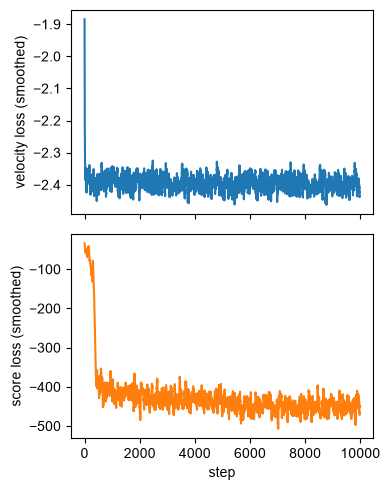

In [27]:
fig, ax = plt.subplots(2, 1, sharex=True, figsize=(4, 5))
ax[0].plot(smooth(hist_b), "-C0")
ax[0].set_ylabel("velocity loss (smoothed)")
ax[1].plot(smooth(hist_s), "-C1")
ax[1].set_xlabel("step")
ax[1].set_ylabel("score loss (smoothed)")
plt.tight_layout()
plt.show()

### 4. Sampling

Push base samples through the built-in samplers (inherited unchanged from `EESI`):
`sample_ode` integrates the probability-flow ODE `dx/dt = b(t, x)`; `sample_sde` integrates
the reverse-time SDE using both `b` and `s`. There is no closed form to compare against
here, so we validate on two physical observables of generated vs. reference configurations:
the pair-distance distribution *g(r)*, and the Lennard-Jones energy.

In [9]:
torch.seed()
n_gen = 2_000
x0 = sample_prior(n_gen, device=device)

# ODE sampling
gen_ode = chunked(lambda c: model.sample(c, n_steps=50), x0)

# eps is a diffusion coef that does not (in principle) change the sampling
gen_sde = chunked(lambda c: model.sample(c, n_steps=100, eps=0.1), x0) 


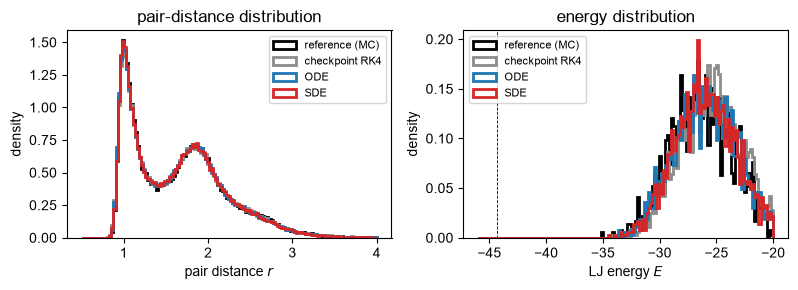

reference (MC)    <E> =  -26.150   std(E) =  2.912   min =  -35.096
checkpoint RK4    <E> =  -25.268   std(E) =  3.010   min =  -34.224
ODE               <E> =  -25.910   std(E) =  2.848   min =  -33.897
SDE               <E> =  -25.912   std(E) =  2.788   min =  -34.492


In [10]:
series = [(x1_all[:n_gen], "reference (MC)", "k"),
          (gen_ckpt,       "checkpoint RK4", "0.55"),
          (gen_ode,        "ODE",            "C0"),
          (gen_sde,        "SDE",            "C3")]

fig, ax = plt.subplots(1, 2, figsize=(8, 3))
rbins = np.linspace(0.5, 4.0, 140)
for x, lbl, c in series:
    ax[0].hist(pair_distances(x), bins=rbins, density=True, histtype="step", lw=2,
               label=lbl, color=c)
ax[0].set_xlabel(r"pair distance $r$"); ax[0].set_ylabel("density")
ax[0].set_title("pair-distance distribution"); ax[0].legend(fontsize=8)

ebins = np.linspace(-46, -20, 140)
for x, lbl, c in series:
    ax[1].hist(energy(x), bins=ebins, density=True, histtype="step", lw=2, label=lbl, color=c)
ax[1].axvline(-44.327, c="k", lw=0.6, ls="--")
ax[1].set_xlabel("LJ energy $E$"); ax[1].set_ylabel("density")
ax[1].set_title("energy distribution"); ax[1].legend(fontsize=8)
plt.tight_layout()
plt.show()

for x, lbl, _ in series:
    e = energy(x)
    print(f"{lbl:16s}  <E> = {e.mean():+8.3f}   std(E) = {e.std():6.3f}   min = {e.min():+8.3f}")

### 5. Entropy estimates

The differential-entropy change between base and target, estimated three ways (all inherited
from `EESI`): `entropy_estimate_dot` (mean of $-b\cdot s$), `entropy_estimate_div` (mean of
$\nabla\!\cdot b$, score-free — Hutchinson with **centered** probes, so the trace is taken on
the 36-dim COM-free subspace, not the 39-dim ambient space), and the running ODE path
integral from `sample_ode_entropy_traj`.

Unlike the XY chain there is no closed form to check against, so the test is *mutual*
agreement of the three estimators. They fail in different ways — `dot` compounds score error
onto drift error, `div` is score-free but higher-variance — so agreement is real evidence.
The batched estimators re-couple, hence `batch_size` again.

In [ ]:

torch.seed()
n_batches = 100
means_dot, means_div = [], []
for _ in range(n_batches):
    idx = torch.randint(0, n_data, (batch_size,), device=device)
    x1 = x1_all[idx]
    x0 = sample_prior(batch_size, device=device)
    x0, x1 = equivariant_ot_couple(x0, x1)
    means_dot.append(model.entropy_estimate_dot(x1, x0).mean().item())
    means_dot.append(model.entropy_estimate(x1,x0,method="dot").mean().item())

    means_div.append(model.entropy_estimate_div(x1, x0).mean().detach().item())

print(f"entropy estimate (b·s)   : {np.mean(means_dot):+.3f} ± {np.std(means_dot):.3f}")
print(f"entropy estimate (div b) : {np.mean(means_div):+.3f} ± {np.std(means_div):.3f}")

entropy estimate (b·s)   : -33.830 ± 1.409
entropy estimate (div b) : -34.674 ± 1.455


entropy estimate (ODE path integral): -33.944


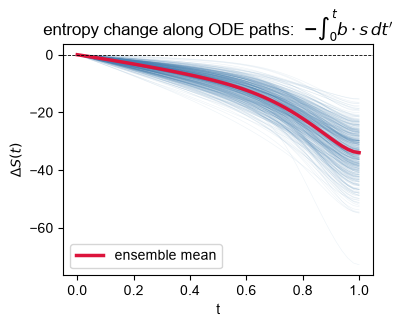

In [31]:
# Running entropy change along many ODE paths.
torch.seed()
x0 = sample_prior(2_000, device=device)
traj, ent_traj, ts = model.sample_ode_entropy_traj(x0, n_steps=50)
ts_c, ent_c = ts.cpu().numpy(), ent_traj.cpu().numpy()
print(f"entropy estimate (ODE path integral): {ent_c[-1].mean():+.3f}")

fig, ax = plt.subplots(figsize=(4, 3))
ax.plot(ts_c, ent_c[:, :500], c="steelblue", lw=0.4, alpha=0.1)
ax.plot(ts_c, ent_c.mean(axis=1), c="crimson", lw=2.5, label="ensemble mean")
ax.axhline(0.0, c="k", lw=0.6, ls="--")
ax.set_xlabel("t"); ax.set_ylabel(r"$\Delta S(t)$")
ax.set_title(r"entropy change along ODE paths:  $-\int_0^t b\cdot s\,dt'$")
ax.legend()
plt.show()

For orientation: the free-energy change for this checkpoint was previously established as
$\Delta F = F_{\rm target} - F_{\rm prior} \approx -26.83$ nats (exact subspace log-det, see
`lj13_sampling.ipynb`). With $\Delta F = \Delta U - T\Delta S$ at $T=1$, the entropy estimates
above and the mean $\Delta U$ below should be mutually consistent — a cross-check on the
*trained* interpolant against a number derived independently from the untrained checkpoint.

In [32]:
x0 = sample_prior(2_000,device=device)
gen_ode, ent, ent_traj = integrate_with_logdet(model.net_b, x0, n_steps=50)
print(ent.mean().cpu())



tensor(-34.2715)


#### Save the models

In [33]:
torch.save(model.net_b.state_dict(), "lj13_b_si_B256.pth")
torch.save(model.net_s.state_dict(), "lj13_s_si_B256.pth")
print("saved lj13_{b,s}_si_B256.pth")

saved lj13_{b,s}_si_B256.pth
